In [14]:
# Main libraries for data analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Additional libraries for time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.arima.utils import ndiffs, nsdiffs
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

# `Part 1`

In [15]:
# load the dateset
df = pd.read_csv('zillow-home-values.csv')

# display the first 5 rows of the dataset
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,31012000,...,28022022,31032022,30042022,31052022,30062022,31072022,31082022,30092022,31102022,30112022
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0,...,261945.0,267644.0,273946.0,280066.0,285121.0,288532.0,290458.0,291103.0,292081.0,292948.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0,...,453150.0,464727.0,478369.0,489712.0,497173.0,499429.0,497572.0,498113.0,500187.0,503109.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0,...,177319.0,179463.0,182812.0,186403.0,189836.0,192064.0,193760.0,195140.0,196787.0,198137.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0,...,570211.0,572145.0,573662.0,576469.0,578706.0,580834.0,581779.0,584566.0,588188.0,590722.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0,...,752025.0,757734.0,760336.0,766163.0,771443.0,776607.0,779281.0,782367.0,788211.0,793924.0


In [16]:
# show the data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27442 entries, 0 to 27441
Columns: 284 entries, RegionID to 30112022
dtypes: float64(275), int64(3), object(6)
memory usage: 59.5+ MB


In [17]:
# Melt the wide-form data into a long-form time series
id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName']

df_long = df.melt(id_vars=id_cols, var_name='Date', value_name='Home Value')

# Convert the Date column to datetime
df_long['Date'] = pd.to_datetime(df_long['Date'], format='%d%m%Y')

# Set the Date column as the index
df_long = df_long.set_index('Date')

df_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0
2000-01-31,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0
2000-01-31,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0
2000-01-31,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0
2000-01-31,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0


In [18]:
# Prepare a filtered copy of the data for Tableau
states = ['CA', 'WA', 'OR', 'AZ', 'NV']

df_tableau = df_long[
    (df_long['State'].isin(states)) &
    (df_long.index.year >= 2010) &
    (df_long.index.year <= 2020)
].copy()

# Save the processed data inside a CSV file for Tableau
df_tableau.to_csv('data-for-tableau.csv')

# Show the first 5 rows of the filtered data for Tableau
df_tableau.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2010-01-31,95992,5,90011,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,209250.0
2010-01-31,96361,8,91331,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,257372.0
2010-01-31,96193,9,90650,zip,CA,CA,Norwalk,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,296430.0
2010-01-31,96083,12,90201,zip,CA,CA,Bell,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,271829.0
2010-01-31,96816,13,92335,zip,CA,CA,Fontana,"Riverside-San Bernardino-Ontario, CA",San Bernardino County,156704.0


In [19]:
# Resample home values by state to yearly frequency (mean, start of calendar year)
df_yearly = (
    df_long
    .groupby('State')['Home Value']
    .resample('YS')
    .mean()
    .reset_index()
)

df_yearly.head()

,State,Date,Home Value
0,AK,2000-01-01,164336.314103
1,AK,2001-01-01,185267.269231
2,AK,2002-01-01,201922.198718
3,AK,2003-01-01,212610.250000
4,AK,2004-01-01,227255.865385


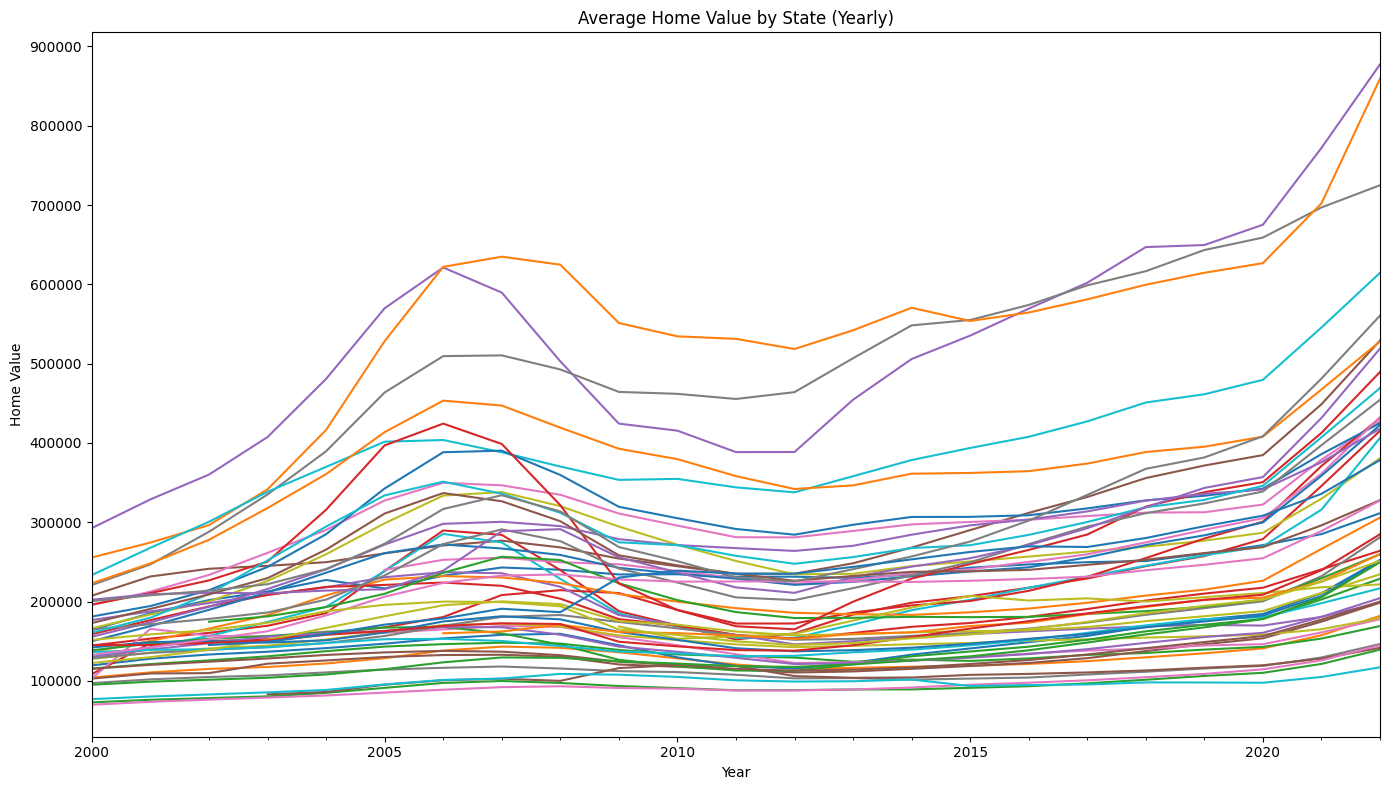

In [20]:
# Pivot so each state is its own column for plotting
df_yearly_pivot = df_yearly.pivot(index='Date', columns='State', values='Home Value')

# Plot each state as a separate line
df_yearly_pivot.plot(figsize=(14, 8), legend=False)
plt.title('Average Home Value by State (Yearly)')
plt.xlabel('Year')
plt.ylabel('Home Value')
plt.tight_layout()
plt.show()  

# `Part 2`

In [21]:
# Goal: forecast the average home price in Oregon for the next 12 months
df_raw = pd.read_csv('zillow-home-values.csv')

id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName']

df_long_or = df_raw.melt(id_vars=id_cols, var_name='Date', value_name='Home Value')

df_long_or['Date'] = pd.to_datetime(df_long_or['Date'], format='%d%m%Y')

# set the Date column as the index
df_long_or = df_long_or.set_index('Date')

df_long_or.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0
2000-01-31,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0
2000-01-31,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0
2000-01-31,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0
2000-01-31,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0


In [22]:
# Filter to Oregon, monthly mean, 2000-01-31 through 2018-12-31
or_ts = (
    df_long_or[df_long_or['State'] == 'OR']
    .loc['2000-01-31':'2018-12-31', 'Home Value']
    .resample('ME')
    .mean()
)

or_ts.head()

Date
2000-01-31    162508.613445
2000-02-29    162913.172269
2000-03-31    163011.125523
2000-04-30    163541.908333
2000-05-31    164176.420833
Freq: ME, Name: Home Value, dtype: float64

In [23]:
# Check for null values
or_ts.isnull().sum()

np.int64(0)

> 📝 **Note:** No further processing is needed

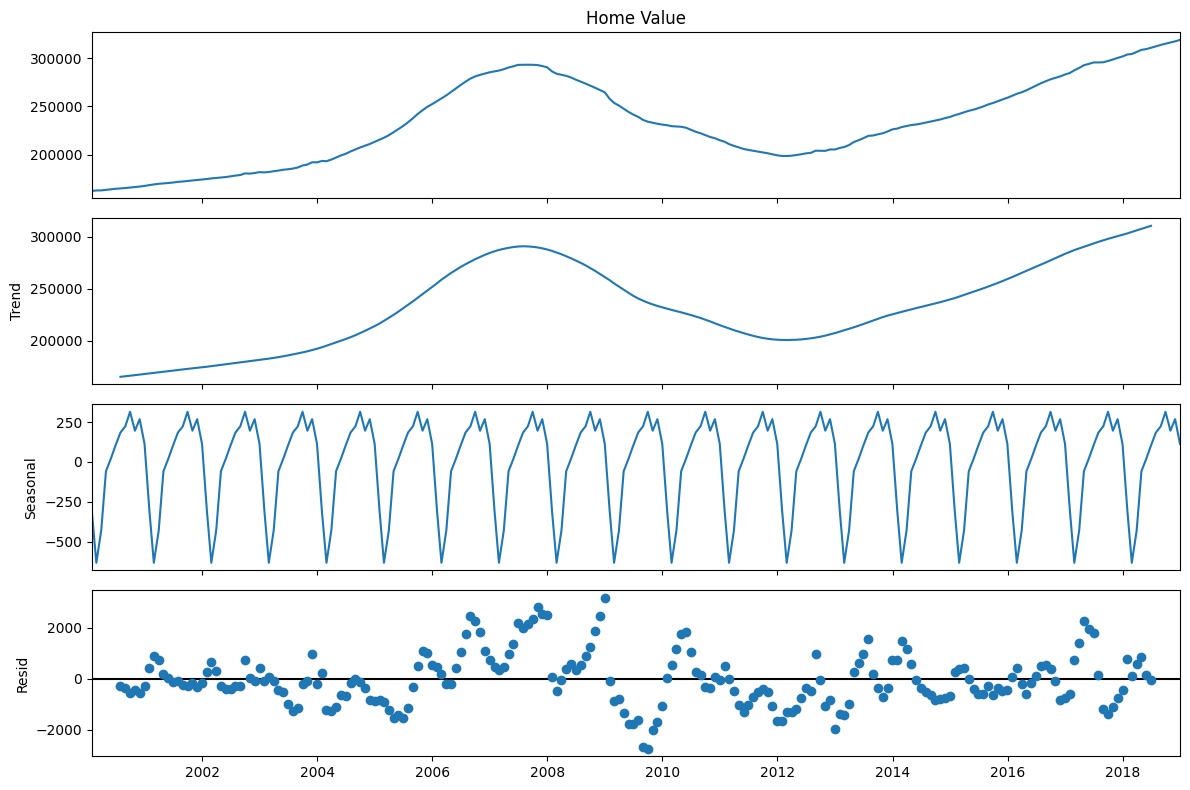

In [24]:
# Decompose the time series to check for seasonality
decomposition = seasonal_decompose(or_ts, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

> 📝 **Notes:** 

> Trend dominates. Rise to a 2007 peak (~295k), crash through 2012 (~200k), then steady recovery to new highs (~310k) — not a simple upward trend.

> Seasonality is negligible. ±750 on a ~250k level (~0.3%), and smaller in magnitude than the residuals.

> Residuals are not white noise. They cluster (positive block 2008–2009, negative 2010) and widen during 2008–2012, so the decomposition misses crisis-period dynamics.

> The seasonal component is ~±750 against a ~250k level (0.3%) and is smaller than the residual noise (±2500) — **so it carries no meaningful signal. `Use a non-seasonal model (ARIMA rather than SARIMA)`, and focus the modeling effort on the trend, which is where all the variation actually lives.**



In [25]:
# running ndiffs and nsdiffs to determine the order of differencing needed for stationarity
print('d =', ndiffs(or_ts, test='adf'))
print('D =', nsdiffs(or_ts, m=12))

d = 2
D = 0


**Differencing order**

`ndiffs` (ADF) returns **d = 2** and `nsdiffs` returns **D = 0**.

- **d = 2** — the series is non-stationary in level and in slope. The trend accelerates into the 2007 peak, reverses through the crash, then recovers, so one round of differencing leaves residual drift.
- **D = 0** — no seasonal differencing needed, consistent with the decomposition, where the seasonal component (~±750 on a ~250k level) is smaller than the residual noise.

Proceeding with a non-seasonal **ARIMA(p, 2, q)**; p and q to be selected from the ACF/PACF of the twice-differenced series.

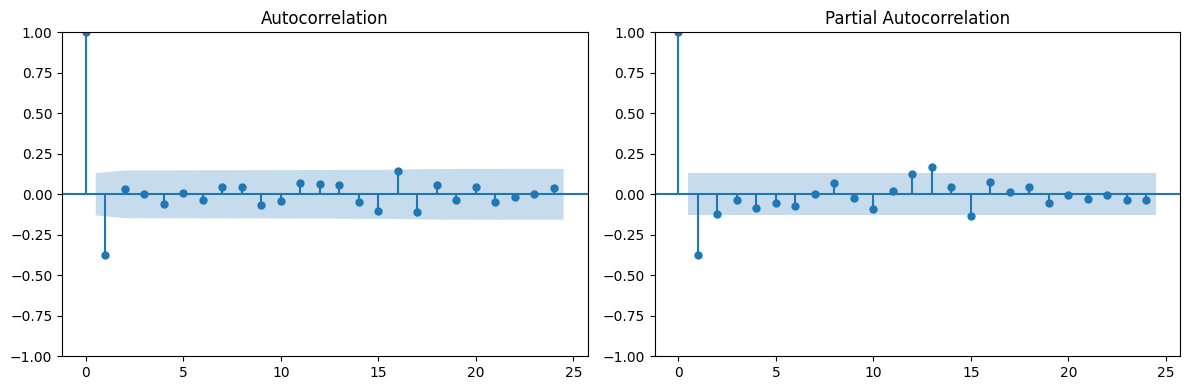

In [26]:
# Differencing the time series to achieve stationarity
or_ts_diff = or_ts.diff().diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(or_ts_diff, ax=axes[0])
plot_pacf(or_ts_diff, ax=axes[1])
plt.tight_layout()
plt.show()

**Initial orders from ACF/PACF**

Plotted on the twice-differenced series (`or_ts.diff().diff()`), which is stationary — all lags beyond the first fall inside the confidence bands.

- **q = 1** — the ACF shows a single significant spike at lag 1 (≈ −0.37) and then cuts off sharply, the classic MA(1) signature.
- **p = 0** — the PACF decays gradually across the early lags rather than cutting off, so there is no clear AR component to include.

Initial candidate: **ARIMA(0, 2, 1)**, to be confirmed against neighbouring orders by AIC.

In [27]:
# Split into train and test (last 12 months held out for testing)
train = or_ts[:-12]
test = or_ts[-12:]

In [28]:
# Fit manual ARIMA(0, 2, 1) on the training data
model = ARIMA(train, order=(0, 2, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Home Value   No. Observations:                  216
Model:                 ARIMA(0, 2, 1)   Log Likelihood               -1726.199
Date:                Sat, 18 Jul 2026   AIC                           3456.399
Time:                        12:14:13   BIC                           3463.131
Sample:                    01-31-2000   HQIC                          3459.119
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0152      0.011     -1.380      0.168      -0.037       0.006
sigma2      5.162e+05   2.21e+04     23.329      0.000    4.73e+05     5.6e+05
Ljung-Box (L1) (Q):                  26.91   Jarque-

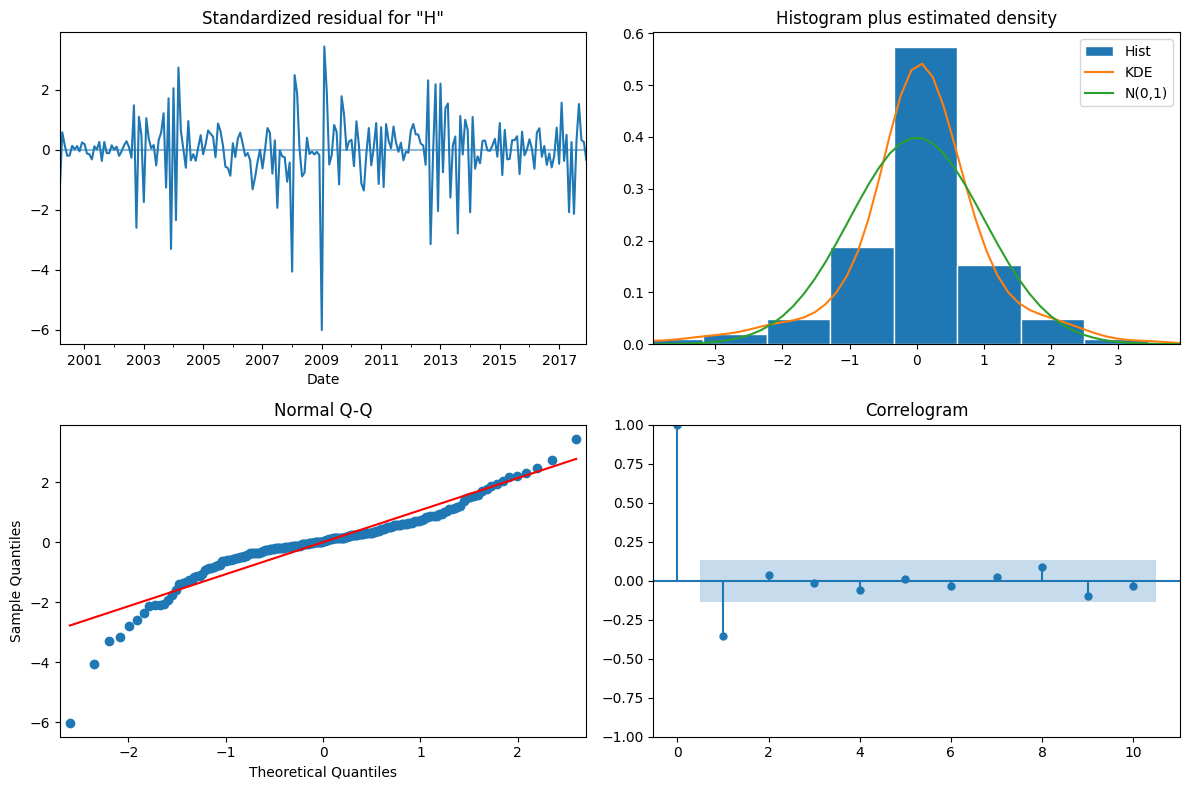

In [29]:
# Diagnostic plots
model_fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

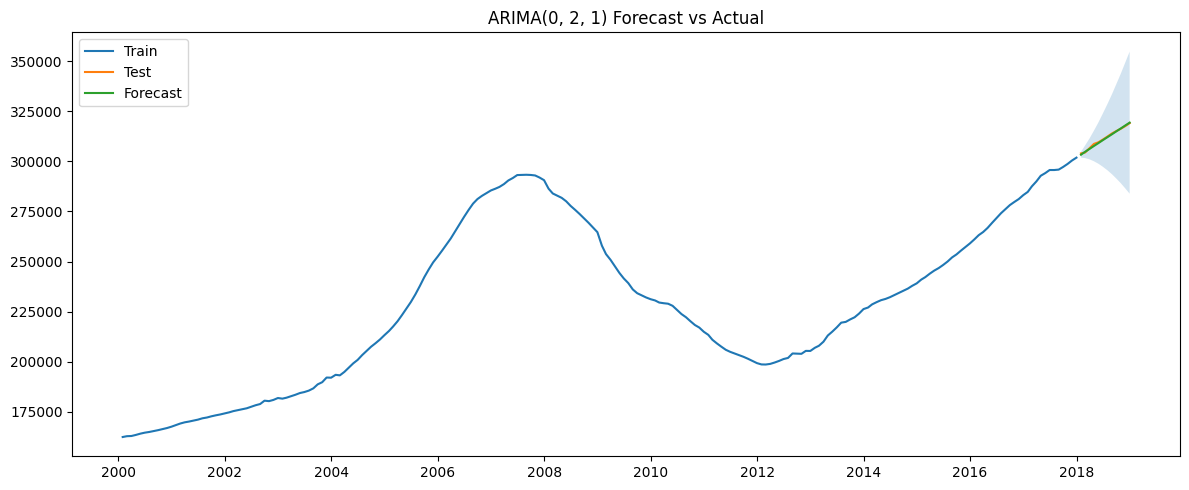

In [30]:
# Forecast the next 12 months
forecast = model_fit.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()
# Plot forecast vs test data
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.2)
plt.legend()
plt.title('ARIMA(0, 2, 1) Forecast vs Actual')
plt.tight_layout()
plt.show()

In [31]:
# Evaluation metrics
mae = mean_absolute_error(test, forecast_mean)
rmse = mean_squared_error(test, forecast_mean) ** 0.5
mape = (abs((test - forecast_mean) / test)).mean() * 100
print(f'MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%')

MAE: 381.78, RMSE: 446.16, MAPE: 0.12%


**Model evaluation**

- **The model missed a pattern.** The correlogram (bottom-right diagnostic plot) still shows a tall bar at lag 1. That bar means one month's error still predicts the next month's error — leftover structure the model should have absorbed but didn't. Ideally every bar sits inside the shaded band.

- **The errors aren't normally distributed.** In the Q-Q plot the points should hug the red line, but the ends curve away. This means the model occasionally makes much larger errors than it expects, mostly during the 2008 housing crash, so its confidence bands are too optimistic.

- **The forecast is very accurate.** A MAPE of 0.12% means predictions were off by about a tenth of a percent on average — roughly $380 on a $300,000 home. MAE = 381.78, RMSE = 446.16.

- **But that number is flattering.** The forecast covers only 12 months, during a calm period of steady price growth. Predicting that a smooth line continues is an easy task; the same model would likely fail badly forecasting through 2008.

- **Verdict.** Acceptable as a baseline. Because the leftover lag-1 pattern is real, **ARIMA(1, 2, 1)** is worth testing to see whether the correlogram cleans up.

---

**Testing the simpler alternative: ARIMA(0, 2, 0)**

The lag-1 spike in the correlogram suggested trying an AR term, but the MA(1) coefficient in the model above is worth checking against the simplest possible alternative — a pure random walk with drift on the twice-differenced series. If the MA(1) term is not statistically significant and AIC does not improve, the simpler model should win.

In [32]:
# Fit the simpler ARIMA(0, 2, 0) on the training data
model_020 = ARIMA(train, order=(0, 2, 0))
model_020_fit = model_020.fit()
print(model_020_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Home Value   No. Observations:                  216
Model:                 ARIMA(0, 2, 0)   Log Likelihood               -1725.649
Date:                Sat, 18 Jul 2026   AIC                           3453.299
Time:                        12:14:14   BIC                           3456.665
Sample:                    01-31-2000   HQIC                          3454.659
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      5.871e+05   2.82e+04     20.794      0.000    5.32e+05    6.42e+05
Ljung-Box (L1) (Q):                  28.80   Jarque-Bera (JB):               367.75
Prob(Q):                              0.00   Pr

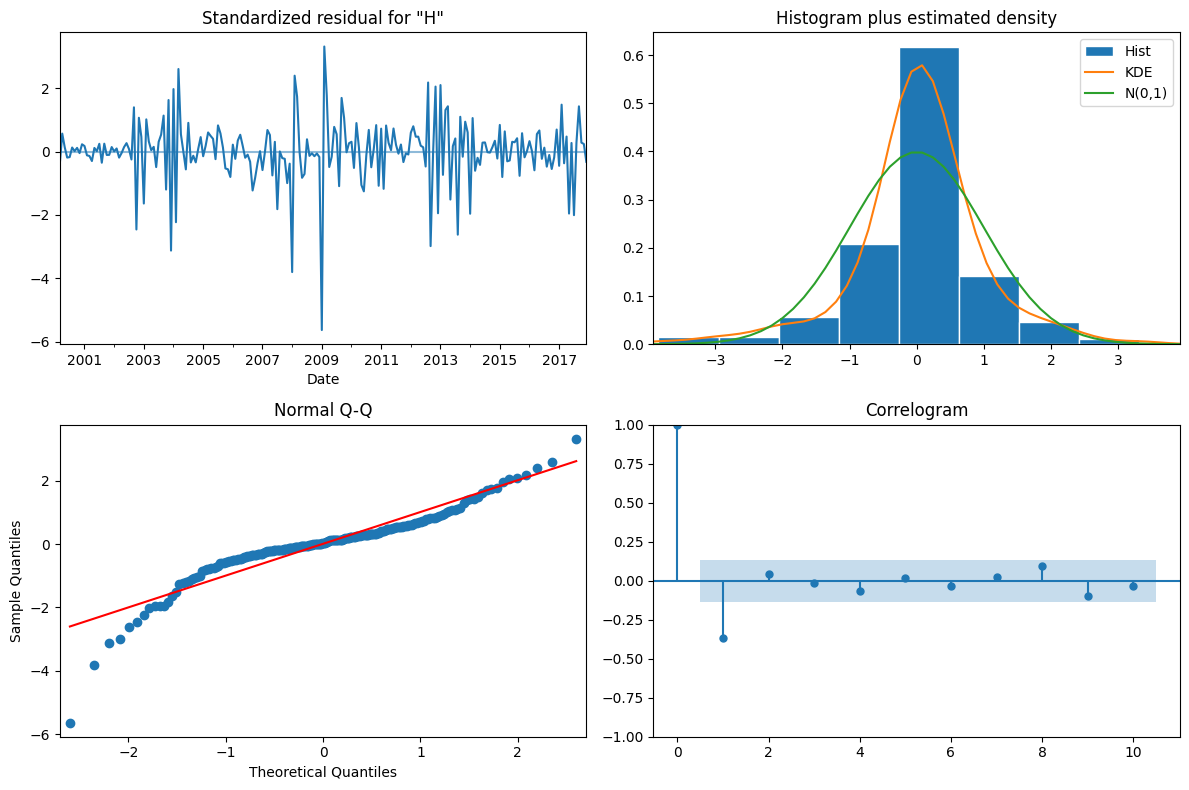

In [33]:
# Diagnostic plots for ARIMA(0, 2, 0)
model_020_fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

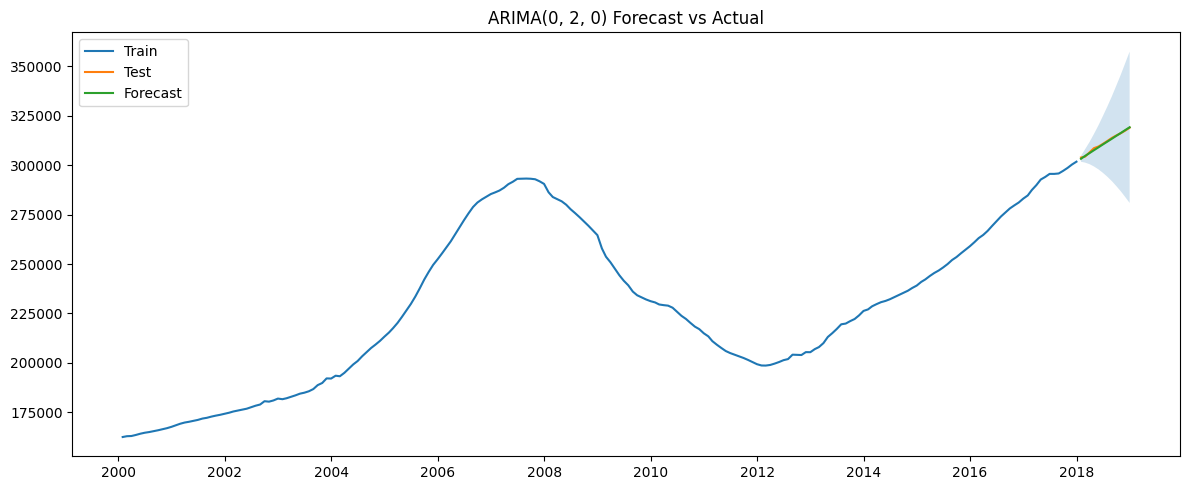

In [34]:
# Forecast the next 12 months with ARIMA(0, 2, 0)
forecast_020 = model_020_fit.get_forecast(steps=12)
forecast_020_mean = forecast_020.predicted_mean
conf_int_020 = forecast_020.conf_int()

# Plot forecast vs test data
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(forecast_020_mean.index, forecast_020_mean, label='Forecast')
plt.fill_between(conf_int_020.index, conf_int_020.iloc[:, 0], conf_int_020.iloc[:, 1], alpha=0.2)
plt.legend()
plt.title('ARIMA(0, 2, 0) Forecast vs Actual')
plt.tight_layout()
plt.show()

In [35]:
# Evaluation metrics for ARIMA(0, 2, 0)
mae_020 = mean_absolute_error(test, forecast_020_mean)
rmse_020 = mean_squared_error(test, forecast_020_mean) ** 0.5
mape_020 = (abs((test - forecast_020_mean) / test)).mean() * 100
print(f'MAE: {mae_020:.2f}, RMSE: {rmse_020:.2f}, MAPE: {mape_020:.2f}%')

# Side-by-side comparison of the two manual models
print()
print(f'ARIMA(0, 2, 1)  AIC: {model_fit.aic:.1f}   MAPE: {mape:.2f}%')
print(f'ARIMA(0, 2, 0)  AIC: {model_020_fit.aic:.1f}   MAPE: {mape_020:.2f}%')

MAE: 384.27, RMSE: 452.16, MAPE: 0.12%

ARIMA(0, 2, 1)  AIC: 3456.4   MAPE: 0.12%
ARIMA(0, 2, 0)  AIC: 3453.3   MAPE: 0.12%


---

In [36]:
# Tune with auto_arima to find the best (p, d, q) order
auto_model = pm.auto_arima(train, seasonal=False, stepwise=True, trace=True, suppress_warnings=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3822.254, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3826.376, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3817.779, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3848.225, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3798.515, Time=0.18 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3859.076, Time=0.22 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3786.724, Time=0.27 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=3815.180, Time=0.07 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=3910.661, Time=0.33 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=3812.385, Time=0.07 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=4015.831, Time=0.40 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=3785.331, Time=0.19 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=3836.870, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0]             : 

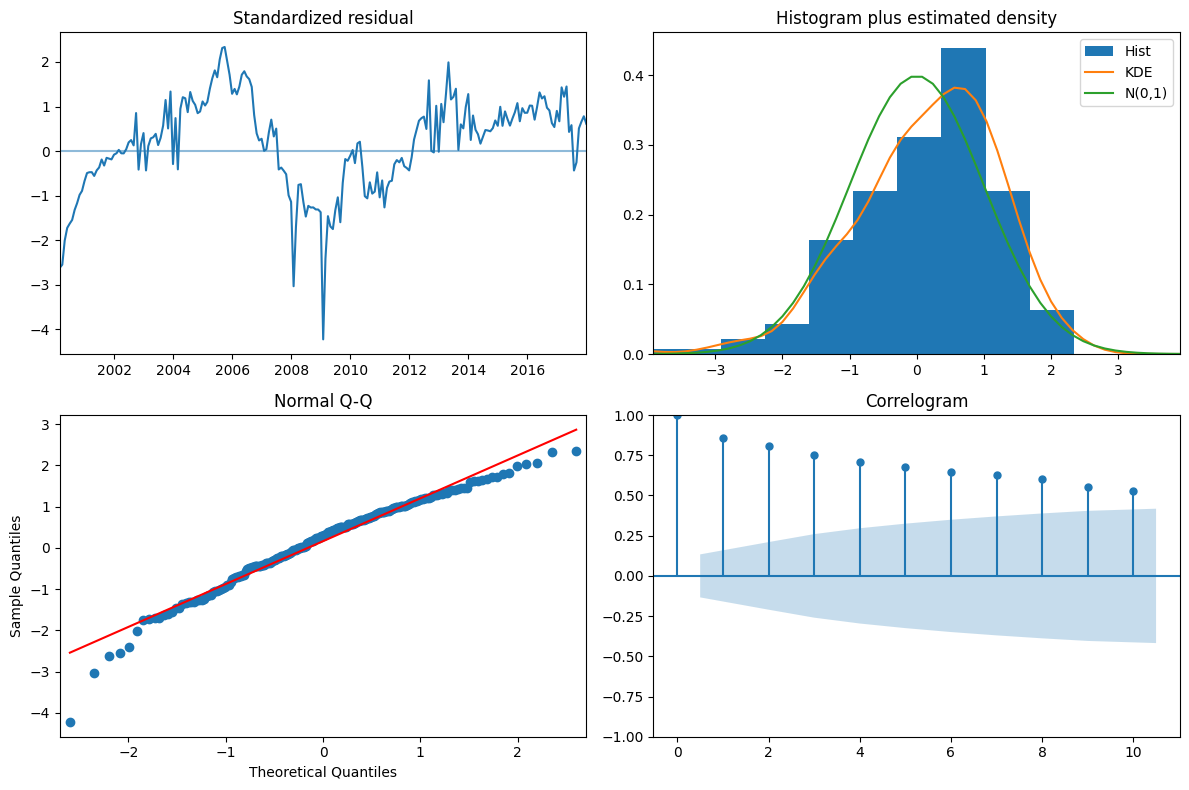

In [37]:
# Diagnostic plots
auto_model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [38]:
# Forecast the next 12 months
auto_forecast, auto_conf_int = auto_model.predict(n_periods=12, return_conf_int=True)
auto_forecast = pd.Series(auto_forecast, index=test.index)

# Evaluation metrics
auto_mae = mean_absolute_error(test, auto_forecast)
auto_rmse = mean_squared_error(test, auto_forecast) ** 0.5
auto_mape = (abs((test - auto_forecast) / test)).mean() * 100
print(f'MAE: {auto_mae:.2f}, RMSE: {auto_rmse:.2f}, MAPE: {auto_mape:.2f}%')

MAE: 6888.61, RMSE: 7754.69, MAPE: 2.19%


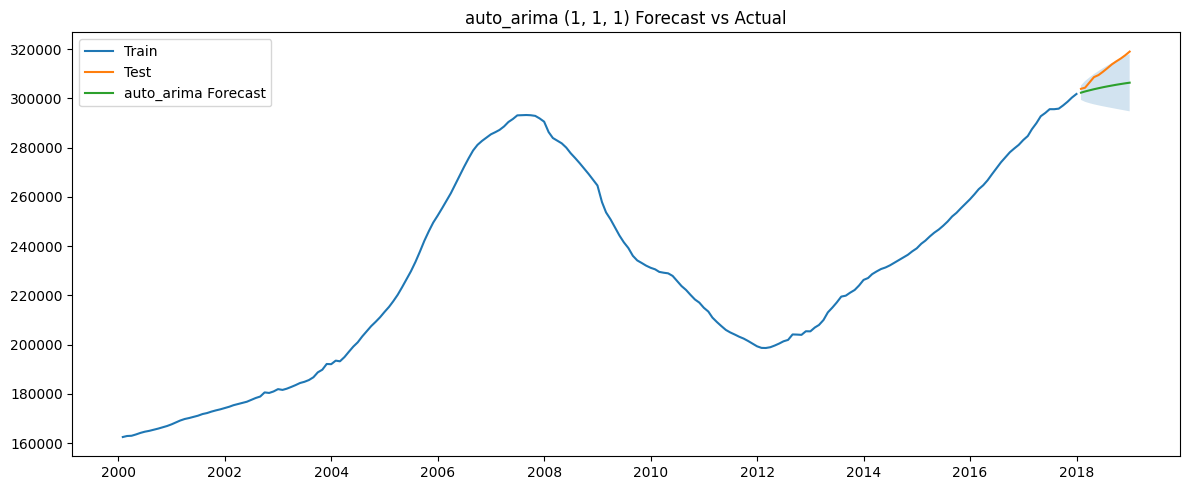

In [39]:
# Plot forecast vs test data
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(auto_forecast.index, auto_forecast, label='auto_arima Forecast')
plt.fill_between(test.index, auto_conf_int[:, 0], auto_conf_int[:, 1], alpha=0.2)
plt.legend()
plt.title(f'auto_arima {auto_model.order} Forecast vs Actual')
plt.tight_layout()
plt.show()

**Final conclusion**

**Selected model: ARIMA(0, 2, 0)**

*What we found*

- **No seasonal pattern worth modelling.** Home values do wobble slightly month to month, but the wobble (~$750) is smaller than the model's own random error (~$2,500) — it's noise, not signal. So no seasonal model.
- **The data needed differencing twice.** Differencing means subtracting each month from the previous one, so the model looks at *changes* instead of raw prices. One round wasn't enough here because prices don't just rise — the rate of rise itself changes (accelerating to 2007, crashing, then recovering). Two rounds fixed it.
- **No extra terms needed.** We fitted ARIMA(0, 2, 1) first, then tested the simpler ARIMA(0, 2, 0) against it. The MA(1) term was not statistically significant and AIC did not improve, so it was dropped. Simpler model, same result.

*Why this model — the evidence*

Three checks all pointed the same way:

- **AIC** (a score that rewards accuracy but penalises unnecessary complexity — lower is better): ARIMA(0, 2, 0) scored 3453.3 versus 3456.4 for the version with an extra term. The simpler model won.
- **Significance test:** the extra term had a p-value of 0.168, well above the usual 0.05 threshold — meaning it couldn't be distinguished from zero. It was doing nothing, so it was removed.
- **Forecast accuracy:** 0.12% MAPE against 2.19% for the automatically selected alternative.

*How well it forecast (12 months ahead)*

| Model | Average error | MAPE |
|---|---|---|
| Our model, differenced twice | ~$382 | **0.12%** |
| Automatic tool, differenced once | ~$6,889 | 2.19% |

MAPE is average percentage error, so 0.12% means predictions were off by about a tenth of a percent — roughly $382 on a $300,000 home.

*The main lesson*

We also ran `auto_arima`, a tool that picks the model automatically. It differenced the data only **once** and was 18× less accurate — its forecast flattened out while real prices kept climbing. The tool never even tested the twice-differenced option. Doing that step manually is what made the difference.

*Limitations*

- The diagnostic plots are honest about one weakness: the residuals (the model's errors) are not perfectly random — there's a mild leftover pattern, and the errors are much larger during 2008–2009 than elsewhere. This doesn't invalidate the model, but it does mean its confidence bands are narrower than they should be.
- The model's biggest mistakes all happened during the 2008 crash. It handles calm periods well and sudden shocks badly.
- The 0.12% accuracy covers one steady year. Forecasting through a crash would be far less accurate.

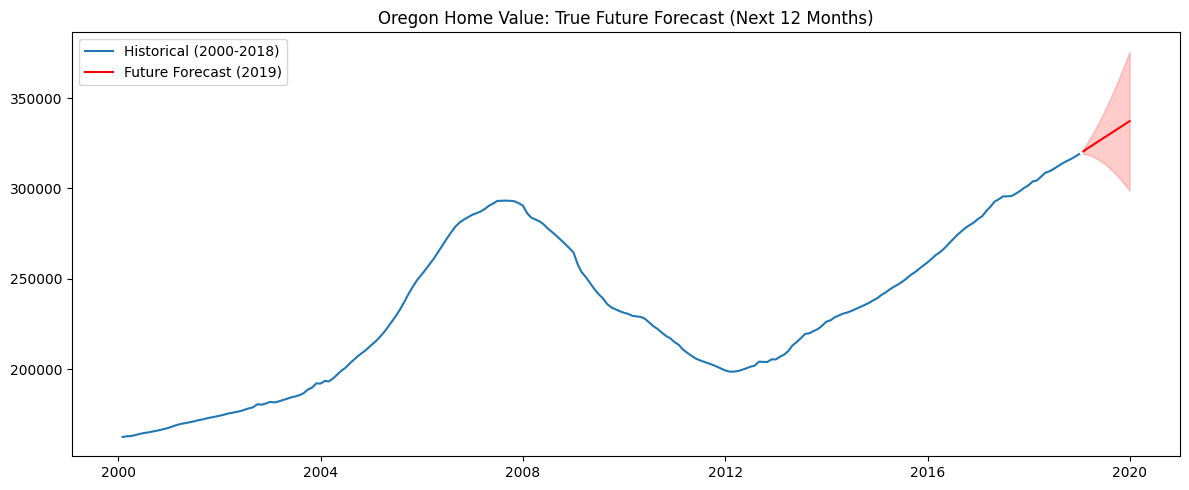

2019-01-31    320543.700000
2019-02-28    322062.738235
2019-03-31    323581.776471
2019-04-30    325100.814706
2019-05-31    326619.852941
2019-06-30    328138.891176
2019-07-31    329657.929412
2019-08-31    331176.967647
2019-09-30    332696.005882
2019-10-31    334215.044118
2019-11-30    335734.082353
2019-12-31    337253.120588
Freq: ME, Name: predicted_mean, dtype: float64

In [40]:
# True future forecast: refit the selected ARIMA(0, 2, 0) on the FULL dataset
final_model = ARIMA(or_ts, order=(0, 2, 0))
final_model_fit = final_model.fit()

# Forecast 12 months beyond the end of the dataset (2018-12-31)
future_forecast = final_model_fit.get_forecast(steps=12)
future_mean = future_forecast.predicted_mean
future_conf_int = future_forecast.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(or_ts.index, or_ts, label='Historical (2000-2018)')
plt.plot(future_mean.index, future_mean, label='Future Forecast (2019)', color='red')
plt.fill_between(future_conf_int.index, future_conf_int.iloc[:, 0], future_conf_int.iloc[:, 1], alpha=0.2, color='red')
plt.legend()
plt.title('Oregon Home Value: True Future Forecast (Next 12 Months)')
plt.tight_layout()
plt.show()

future_mean

In [41]:
# Summarize the forecast
final_month_value = future_mean.iloc[-1]
pct_change = (future_mean.iloc[-1] - or_ts.iloc[-1]) / or_ts.iloc[-1] * 100

print(f'Predicted Oregon home value in {future_mean.index[-1].date()}: ${final_month_value:,.2f}')
print(f'Percent change over the 12-month forecast: {pct_change:.2f}%')

Predicted Oregon home value in 2019-12-31: $337,253.12
Percent change over the 12-month forecast: 5.71%


# `Part 3`

### Tablea Workbook
Link: https://public.tableau.com/shared/G24BFXTTG?:display_count=n&:origin=viz_share_link